# SIRENs: the infinite-width effect
This notebook aims to show the behaviour of SIRENs networks as the width of the network goes to infinity. This investigation is motivated by the fact that the infinite-width NTK does not show the periodical behaviour shown at finite-width by the empirical NTK.

## Setup

In [25]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.PINNs import PINN, PINNConfig, TrainingConfig
from src.SIRENs import SIREN, SIRENConfig
from src.spectral_analysis import compute_ntk
from src.numerical_solvers import rk4_solve

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures -> {FIGURES_DIR}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

ROOT = /Users/marcogalliani/Projects/PINNs-and-spectral-bias
Figures -> /Users/marcogalliani/Projects/PINNs-and-spectral-bias/examples/ntk-nn/figures
Device: mps


In [26]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.PINNs import PINN, PINNConfig, TrainingConfig
from src.SIRENs import SIREN, SIRENConfig
from src.spectral_analysis import compute_ntk
from src.numerical_solvers import rk4_solve

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures -> {FIGURES_DIR}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

ROOT = /Users/marcogalliani/Projects/PINNs-and-spectral-bias
Figures -> /Users/marcogalliani/Projects/PINNs-and-spectral-bias/examples/ntk-nn/figures
Device: mps


In [27]:
class ForcedFirstOrderODE:
    """
    z' = sum_k A_k sin(2*pi*f_k*t + phi_k)
    """

    def __init__(self, freqs, amps, phases):
        self.freqs  = list(freqs)
        self.amps   = list(amps)
        self.phases = list(phases)

    def _forcing(self, t, sin_fn):
        return sum(
            A * sin_fn(2 * np.pi * f * t + ph)
            for f, A, ph in zip(self.freqs, self.amps, self.phases)
        )

    def rhs_np(self, t, z):
        return [self._forcing(t, np.sin)]

    def rhs_torch(self, t, z):
        return self._forcing(t, torch.sin)

Grid: 500 points on [0, 2.0]


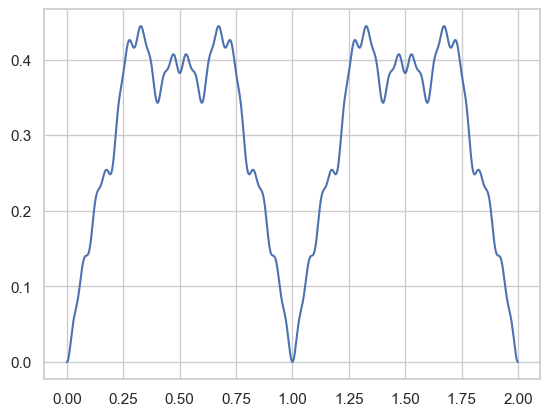

In [28]:
# ODE parameters
FREQS = [1.0, 2.0, 5.0, 10.0, 20.0]
AMPS = [1.0, 1.0, 1.0, 1.0, 1.0]
PHASES = [0, 0, 0, 0, 0]

# Decay rate of the ODE  z' = -ALPHA*z + F(t).  ForcedFirstOrderODE.rhs returns the
# forcing F(t) only (no z-dependence), so this notebook studies the forcing-only case
# ALPHA = 0 — the PINN residual operator then reduces to ∂_t.
ALPHA = 0.0

T     = 2.0
N_GRID = 500

t_eval = np.linspace(0, T, N_GRID, dtype=np.float32)
print(f"Grid: {N_GRID} points on [0, {T}]")

ode    = ForcedFirstOrderODE(FREQS, AMPS, PHASES)

y_fitted = rk4_solve(ode.rhs_np, [0], t_eval)

plt.plot(t_eval, y_fitted)
plt.show()

## SIREN

In [29]:
# --- Instantiate all architectures at random initialisation ---
WIDTH, DEPTH = 512, 3
SIREN_OMEGA = 20


mlp     = PINN(PINNConfig(n_vars=1, width=WIDTH, depth=DEPTH)).to(DEVICE)
siren   = SIREN(SIRENConfig(n_vars=1, width=WIDTH, depth=DEPTH, omega_0=SIREN_OMEGA)).to(DEVICE)

MODELS = {
    "MLP (Tanh)":  mlp,
    "SIREN":       siren,
}

print(f"{'Architecture':<20} {'Params':>10}")
print("-" * 32)
for name, m in MODELS.items():
    P = sum(p.numel() for p in m.parameters())
    print(f"{name:<20} {P:>10,}")

Architecture             Params
--------------------------------
MLP (Tanh)              264,193
SIREN                   264,193


In [30]:
print("Computing NTK matrices at random initialisation...")
print(f"  Grid: {len(t_eval)} points  |  arch width={WIDTH}, depth={DEPTH}\n")

ntk_matrices    = {}
ntk_eigenvalues = {}
ntk_eigenvectors = {}

for name, model in MODELS.items():
    print(f"  {name}...", end=" ", flush=True)
    K = compute_ntk(model, t_eval, device=DEVICE)
    vals, vecs = np.linalg.eigh(K)
    ntk_matrices[name]     = K
    ntk_eigenvalues[name]  = vals[::-1].copy()
    ntk_eigenvectors[name] = vecs[:, ::-1].copy()
    eff_rank = int((vals.sum() ** 2) / (vals ** 2).sum())   # participation ratio
    print(f"λ_max={vals[-1]:.2e}  λ_min={vals[vals > 0].min():.2e}  eff_rank≈{eff_rank}")

# PINN NTK: same MLP backbone but Jacobian is ∂R/∂θ instead of ∂f/∂θ
print(f"  PINN NTK (K_ff)...", end=" ", flush=True)
K_pinn = mlp.ntk(t_eval, ode.rhs_torch, device=DEVICE)

vals_p, vecs_p = np.linalg.eigh(K_pinn)
ntk_matrices["PINN NTK"]     = K_pinn
ntk_eigenvalues["PINN NTK"]  = vals_p[::-1].copy()
ntk_eigenvectors["PINN NTK"] = vecs_p[:, ::-1].copy()
eff_rank_p = int((vals_p.sum() ** 2) / (vals_p ** 2).sum())
print(f"λ_max={vals_p[-1]:.2e}  λ_min={vals_p[vals_p > 0].min():.2e}  eff_rank≈{eff_rank_p}")

ARCH_NAMES = list(ntk_matrices.keys())
PALETTE    = dict(zip(ARCH_NAMES, sns.color_palette("tab10", len(ARCH_NAMES))))

Computing NTK matrices at random initialisation...
  Grid: 500 points  |  arch width=512, depth=3

  MLP (Tanh)... λ_max=4.78e+04  λ_min=7.00e-06  eff_rank≈1
  SIREN... λ_max=6.71e+05  λ_min=7.87e-04  eff_rank≈17
  PINN NTK (K_ff)... λ_max=1.79e+04  λ_min=1.34e-06  eff_rank≈1


## Infinite-width limit

In [31]:
SW2_INF, SB2_INF = 1.0, 0.2        

_GH = 20
_ghx, _ghw = np.polynomial.hermite.hermgauss(_GH)
_ghx = np.sqrt(2.0) * _ghx
_ghw = _ghw / np.sqrt(np.pi)

def _tanh_expectations(var, Cov):
    """E[σ(u)σ(v)] and E[σ'(u)σ'(v)] for (u,v)~N(0,Λ), elementwise over a grid (tanh)."""
    sd = np.sqrt(np.clip(var, 1e-30, None))
    rho = np.clip(Cov / np.outer(sd, sd), -1.0, 1.0)
    comp = np.sqrt(np.clip(1.0 - rho ** 2, 0.0, None))
    Ess = np.zeros_like(Cov); Edd = np.zeros_like(Cov)
    for p in range(_GH):
        u = sd[:, None] * _ghx[p]; tu = np.tanh(u); du = 1.0 - tu ** 2
        for q in range(_GH):
            v = sd[None, :] * (rho * _ghx[p] + comp * _ghx[q]); w = _ghw[p] * _ghw[q]
            Ess += w * tu * np.tanh(v)
            Edd += w * du * (1.0 - np.tanh(v) ** 2)
    return (Ess + Ess.T) / 2.0, (Edd + Edd.T) / 2.0

def infinite_width_ntk(t, depth, sigma_w2=1.0, sigma_b2=0.2):
    """Deterministic NTK Θ_∞ of an infinitely wide tanh MLP with `depth` weight layers."""
    X = np.asarray(t, dtype=float).reshape(-1, 1)
    Sigma = sigma_w2 * (X @ X.T) + sigma_b2          # Σ^(1)
    Theta = Sigma.copy()                              # Θ^(1)
    for _ in range(depth - 1):
        Ess, Edd = _tanh_expectations(np.diag(Sigma).copy(), Sigma)
        Sigma = sigma_w2 * Ess + sigma_b2            # Σ^(l+1)
        Theta = Sigma + Theta * (sigma_w2 * Edd)     # Θ^(l+1)
    return Theta
    
def _sincos_expectations(var, Cov):
    """E[sin u sin v]=e^{-(a+b)/2}sinh(c) and E[sin'u sin'v]=E[cos u cos v]=e^{-(a+b)/2}cosh(c),
    in overflow-safe form (SIREN pre-activation variances are O(ω₀²)).
    
    Parameters
    ----------
    
    
    """
    a = var[:, None]; b = var[None, :]; c = Cov
    half = (a + b) / 2.0
    Ess = 0.5 * (np.exp(c - half) - np.exp(-c - half))
    Ecc = 0.5 * (np.exp(c - half) + np.exp(-c - half))
    return Ess, Ecc

def infinite_width_siren(t, depth, scale1, offset1, gw_hidden=2.0):
    """Θ_∞ of a SIREN (sin activation, closed-form expectations). scale1/offset1 are
    the effective first-layer pre-activation variance constants (∝ ω₀²·Var(W),Var(b))."""
    X = np.asarray(t, float).reshape(-1, 1)
    Lam = scale1 * (X @ X.T) + offset1
    Theta = Lam.copy()
    for _ in range(depth - 2):                              # hidden sin layers
        Ess, Ecc = _sincos_expectations(np.diag(Lam).copy(), Lam)
        Lam = gw_hidden * Ess
        Theta = Lam + Theta * (gw_hidden * Ecc)
    Ess, _ = _sincos_expectations(np.diag(Lam).copy(), Lam)  # linear readout
    return Ess + Theta

def apply_ode_operator(Theta, t, alpha):
    """(∂_t+α)(∂_{t'}+α) Θ by finite differences (the PINN ∞-width kernel)."""
    h = t[1] - t[0]
    d_t = np.gradient(Theta, h, axis=0); d_tp = np.gradient(Theta, h, axis=1)
    d_ttp = np.gradient(d_tp, h, axis=0)
    return d_ttp + alpha * d_t + alpha * d_tp + alpha ** 2 * Theta

# effective init constants (chosen to match this notebook's finite kernels)
SW2_F, SB2_F = 0.5, 0.05            # Fourier tanh layers
S1_S, S0_S   = 600.0, 300.0         # SIREN effective first-layer scale (≈ 2·ω₀²/3, ω₀=30)

K_inf_mlp  = infinite_width_ntk(t_eval, DEPTH, SW2_INF, SB2_INF)
K_inf_siren = infinite_width_siren(t_eval, DEPTH, S1_S, S0_S)

K_inf_pinn = apply_ode_operator(K_inf_mlp, t_eval, ALPHA)

# pair each empirical kernel with its infinite-width limit
INF_PAIRS = {
    "MLP (Tanh)":  (ntk_matrices["MLP (Tanh)"],  K_inf_mlp),
    "SIREN":       (ntk_matrices["SIREN"],       K_inf_siren),
    "PINN NTK":    (ntk_matrices["PINN NTK"],     K_inf_pinn),
}

def _eff_rank(K):
    w = np.linalg.eigvalsh(_corr(K)); w = w[w > 1e-12]; return w.sum() ** 2 / (w ** 2).sum()
    
def _corr(K):
    d = np.sqrt(np.diag(K).clip(0)); d = np.where(d == 0, 1.0, d); return K / np.outer(d, d)

sl = slice(2, -2)   # trim finite-difference edges (matters only for PINN)
print(f"{'architecture':<13} {'corr-dist':>9} {'eff_rank emp':>13} {'eff_rank Θ∞':>12}")
print("-" * 50)
for name, (K_emp, K_inf) in INF_PAIRS.items():
    cd = (np.linalg.norm(_corr(K_inf)[sl, sl] - _corr(K_emp)[sl, sl])
          / np.linalg.norm(_corr(K_emp)[sl, sl]))
    print(f"{name:<13} {cd:>9.3f} {_eff_rank(K_emp):>13.1f} {_eff_rank(K_inf):>12.1f}")

architecture  corr-dist  eff_rank emp  eff_rank Θ∞
--------------------------------------------------
MLP (Tanh)        0.030           1.2          1.2
SIREN             0.382          17.4         28.0
PINN NTK          0.339           1.2          1.9


Compare GP regression with the infinite-width kernel to SIREN training

GP mean vs true ODE solution: RMSE = 6.60e-04


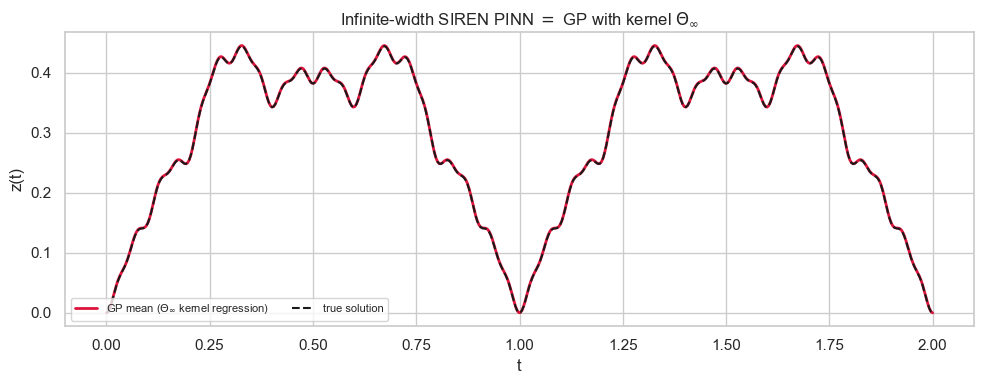

In [32]:
# Infinite-width SIREN  ==  GP regression with the Θ_∞ kernel.
# ODE of this notebook:  z'(t) = F(t),  z(0) = Y0    (ALPHA = 0  ->  residual operator L = ∂_t)
# The PINN/GP equivalence treats Θ_∞ as the GP prior covariance and conditions on
#   * the residual observations  L z = g  at collocation points, and
#   * the initial condition       z(0) = Y0.
Theta  = K_inf_siren                       # GP prior covariance  Θ_∞(t, t')  of the SIREN
t_grid = t_eval                            # uniform grid (required by the finite-difference operators)
Y0     = 0.0                               # initial condition fed to rk4_solve above
z_true = np.asarray(y_fitted).ravel()      # reference ODE solution
def g_np(t):                               # forcing  F(t) = L z  (= z' since ALPHA = 0)
    return ode._forcing(np.asarray(t, dtype=float), np.sin)

h = float(t_grid[1] - t_grid[0])
def L_on_first(K):  return np.gradient(K, h, axis=0) + ALPHA * K   # (∂_t  + α) on the 1st argument
def L_on_second(K): return np.gradient(K, h, axis=1) + ALPHA * K   # (∂_t' + α) on the 2nd argument

L_left  = L_on_first(Theta)                                        # L_t  Θ(t, t')
L_right = L_on_second(Theta)                                       # L_t' Θ(t, t')
LL      = L_on_first(L_on_second(Theta))                           # L_t L_t' Θ  (residual–residual)

# Observations: residual = 0 at N_COL interior collocation points + IC at t = 0
N_COL  = N_GRID-2
ix_f   = np.linspace(1, N_GRID-2, N_GRID-2).astype(int)
ic_idx = 0

A  = LL[np.ix_(ix_f, ix_f)]                 # residual–residual  Cov(L z_i, L z_j)
b  = L_left[ix_f, ic_idx][:, None]          # residual–IC cross  Cov(L z_i, z(0))
cc = np.array([[Theta[ic_idx, ic_idx]]])    # IC–IC              Cov(z(0), z(0))
Gram = np.block([[A, b], [b.T, cc]])
Gram += 1e-8 * np.mean(np.diag(Gram)) * np.eye(N_COL + 1)   # jitter
targets = np.concatenate([g_np(t_grid[ix_f]), [Y0]])        # L z = g,  z(0) = Y0

# cross-covariance of every eval point with the observations:  Cov(z(t), obs)
Kvec = np.concatenate([L_right[:, ix_f], Theta[:, ic_idx][:, None]], axis=1)
sol  = np.linalg.solve(Gram, targets)
f_gp = Kvec @ sol                                           # posterior mean
post_cov = Theta - Kvec @ np.linalg.solve(Gram, Kvec.T)
f_gp_std = np.sqrt(np.clip(np.diag(post_cov), 0.0, None))

print(f"GP mean vs true ODE solution: RMSE = {np.sqrt(np.mean((f_gp - z_true) ** 2)):.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, f_gp, color="crimson", lw=2.0,
        label=r"GP mean ($\Theta_\infty$ kernel regression)")
ax.plot(t_grid, z_true, "k--", lw=1.5, label="true solution")

ax.set(xlabel="t", ylabel="z(t)",
       title=r"Infinite-width SIREN PINN $=$ GP with kernel $\Theta_\infty$")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "siren_pinn_gp_predictor.png", dpi=150, bbox_inches="tight")
plt.show()

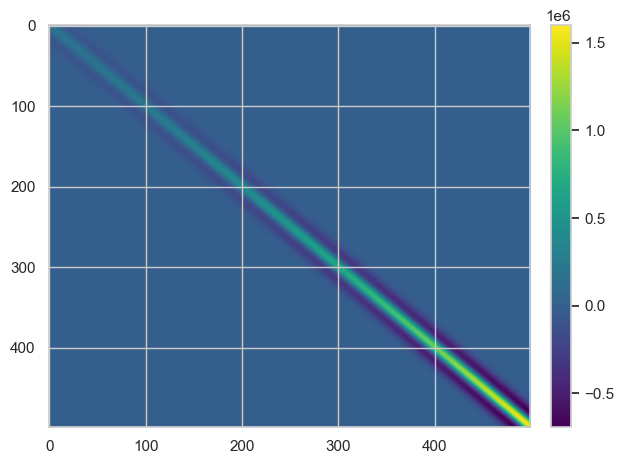

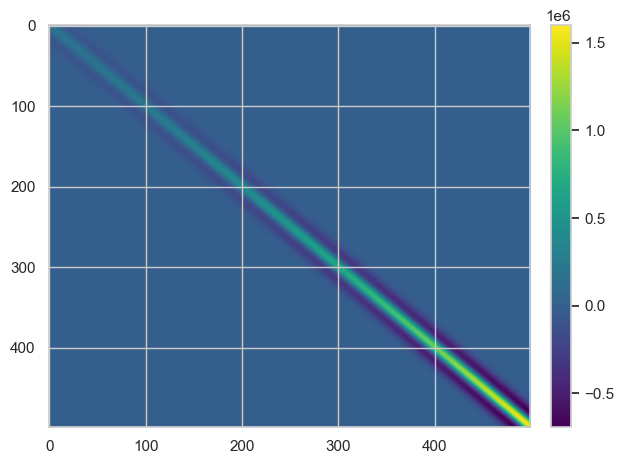

In [ ]:
im = plt.imshow(_corr(Gram), cmap="viridis", aspect="auto",
                       extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]], vmin=0, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

K_pinn_siren = siren.ntk(t_eval, ode.rhs_torch, device=DEVICE)

im = plt.imshow(_corr(Gram), cmap="viridis", aspect="auto",
                       extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]], vmin=0, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()